<a href="https://colab.research.google.com/github/frank-gr588/ml-lab-itmo/blob/lab1/lab1ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная 1 (supervised): прогноз сильного снегопада в Санкт-Петербурге

**Что делаем.** По погоде сегодня в 12:00 предсказываем, будет ли в следующие 24 часа **сильный снегопад (2 см снега и больше)**. Ответ "да / нет", поэтому это задача **классификации**.

**Данные.** Почасовая погода СПб с сайта Open-Meteo (с 2018 года).

**Модель.** kNN . Идея простая - чтобы понять, что будет завтра, ищем в прошлом `k` дней с самой похожей погодой и смотрим, в какой доле из них был сильный снегопад. Эта доля и есть вероятность. Если вероятность выше порога - говорим "будет снегопад".


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, confusion_matrix

## Первый этап - загружаем данные

In [33]:

# строка "time," - это заголовок таблицы
file_name = "spb_weather.csv"
lines_to_skip = 0
with open(file_name, encoding="utf-8", errors="ignore") as f:
    for line in f:
        if line.startswith("time,"):
            break
        lines_to_skip += 1

raw = pd.read_csv(file_name, skiprows=lines_to_skip, encoding_errors="replace")

# форматирование названий колонок "snowfall (cm)" -> "snowfall"
raw.columns = [name.split(" (")[0] for name in raw.columns]

raw["time"] = pd.to_datetime(raw["time"])
raw = raw.drop_duplicates("time").set_index("time").sort_index()
raw = raw.asfreq("h") # чтобы каждый час был в таблице
raw = raw.interpolate(limit=6) # короткие пропуски заполняем средним между соседями

## Второй этап - что предсказываем и по чему

**Таргет** для каждого дня считаем, сколько снега выпадет в следующие 24 часа, и ставим:
* `heavy = 1`, если снега 2 см и больше;
* `heavy = 0`, если меньше.

**Признаки** температура, давление, влажность и т.д.

In [34]:
data = raw.copy()

# Таргет
# rolling(24).sum() - сумма снегопада за последние 24 часа
# shift(-24) - next 24 часа
data["snow_next_24h"] = data["snowfall"].rolling(24).sum().shift(-24)

# признаки прошлого
data["snow_past_24h"] = data["snowfall"].rolling(24).sum()
data["precip_past_24h"] = data["precipitation"].rolling(24).sum()
data["pressure_change_3h"] = data["pressure_msl"].diff(3)
data["pressure_change_6h"] = data["pressure_msl"].diff(6)
data["pressure_change_24h"] = data["pressure_msl"].diff(24)
data["water_vapour_change_12h"] = data["total_column_integrated_water_vapour"].diff(12)

# признаки
cols = ["temperature_2m", "relative_humidity_2m", "pressure_msl", "pressure_change_3h",
              "pressure_change_6h", "pressure_change_24h", "wind_speed_10m", "cloud_cover",
              "snow_depth", "snow_past_24h", "precip_past_24h", "total_column_integrated_water_vapour",
              "wet_bulb_temperature_2m", "wind_speed_100m", "boundary_layer_height", "water_vapour_change_12h"]


data = data[data.index.hour == 12]  # в 12:00
data = data[data.index.month.isin([10, 11, 12, 1, 2, 3, 4])]   # только холодное время
data = data.dropna(subset=cols + ["snow_next_24h"])   # выкидываем строки с пропусками

# октябрь-апрель - один сезоном, сезон 2018 = октябрь 2018 - апрель 2019
data["season"] = data.index.year
data.loc[data.index.month < 5, "season"] = data["season"] - 1

# оставляем только полные сезоны (~212 дней)
days_in_season = data.groupby("season").size()
full_seasons = days_in_season[days_in_season >= 150].index
data = data[data["season"].isin(full_seasons)].copy()

# сильный снегопад или нет
data["heavy"] = (data["snow_next_24h"] >= 2).astype(int)

# метрики
def weather_type(code):
    # код погоды WMO превращаем в понятную группу
    if code in (0, 1): return "clear"
    if code in (2, 3): return "cloudy"
    if code in (45, 48): return "fog"
    if 51 <= code <= 57: return "drizzle"
    if 61 <= code <= 67: return "rain"
    if 80 <= code <= 82: return "showers"
    if 71 <= code <= 77 or code in (85, 86): return "snow"
    return "other"

data["weather"] = data["weather_code"].apply(weather_type)

# Направление ветра превращаем в 8 сторон света
sides = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
data["wind"] = [sides[int(x)] for x in ((data["wind_direction_10m"] + 22.5) // 45 % 8)]

data["month"] = data.index.strftime("%m")

print("Полные сезоны:", list(full_seasons))
print("Всего дней (строк):", len(data))
print("Дней с сильным снегопадом:", data["heavy"].sum(), f"({data['heavy'].mean():.1%})")
data[["snow_next_24h", "heavy", "season"] + cols[:4]].head()

Полные сезоны: [2018, 2019, 2020, 2021, 2022, 2024, 2025]
Всего дней (строк): 1485
Дней с сильным снегопадом: 142 (9.6%)


,snow_next_24h,heavy,season,temperature_2m,relative_humidity_2m,pressure_msl,pressure_change_3h
time,,,,,,,
2018-10-01 12:00:00,0.0,0,2018,12.2,72,1008.9,0.4
2018-10-02 12:00:00,0.0,0,2018,9.4,86,1001.8,-0.5
2018-10-03 12:00:00,0.0,0,2018,10.2,84,997.4,-0.2
2018-10-04 12:00:00,0.0,0,2018,5.8,60,1008.3,2.9
2018-10-05 12:00:00,0.0,0,2018,5.3,94,1007.7,-5.0


**One-hot кодирование.** Для каждой метки делаем отдельную колонку из нулей и единиц (`month_01`, `month_02` ... )

In [35]:
dummies = pd.get_dummies(data[["month", "weather", "wind"]]).astype(float)
dummy_cols = list(dummies.columns)
data = pd.concat([data, dummies], axis=1)

# Третий этап - деление на train / val / test
Делим по сезонам, последний **test**, два перед ним **val**, остальные **train**

In [36]:
seasons = sorted(full_seasons)
test_seasons = seasons[-1:]
val_seasons = seasons[-3:-1]
train_seasons = seasons[:-3]
print("train:", train_seasons, "| val:", val_seasons, "| test:", test_seasons)

train = data[data["season"].isin(train_seasons)]
val = data[data["season"].isin(val_seasons)]
test = data[data["season"].isin(test_seasons)]

y_train = train["heavy"].to_numpy()
y_val = val["heavy"].to_numpy()
y_test = test["heavy"].to_numpy()

pd.DataFrame({"дней": [len(train), len(val), len(test)],
              "сильных снегопадов": [y_train.sum(), y_val.sum(), y_test.sum()],
              "доля сильных": [y_train.mean(), y_val.mean(), y_test.mean()]},
             index=["train", "val", "test"]).round(3)

train: [2018, 2019, 2020, 2021] | val: [2022, 2024] | test: [2025]


,дней,сильных снегопадов,доля сильных
train,849,81,0.095
val,424,50,0.118
test,212,11,0.052


## Четвёртый этап - train

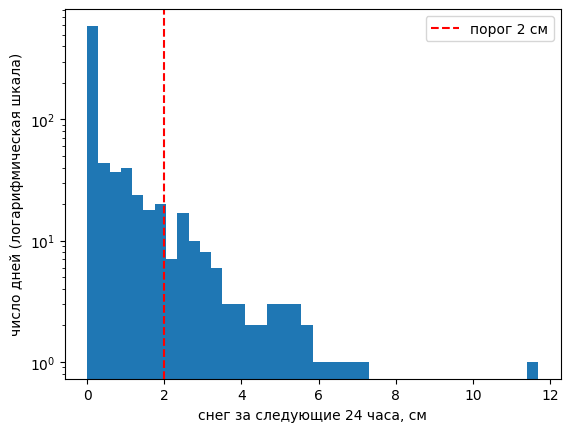

Сильные снегопады - это 9.5% дней.


In [37]:
# сколько снега за сутки, красная линия - 2 см
plt.hist(train["snow_next_24h"], bins=40)
plt.axvline(2, color="red", linestyle="--", label="порог 2 см")
plt.yscale("log")
plt.xlabel("снег за следующие 24 часа, см")
plt.ylabel("число дней (логарифмическая шкала)")
plt.legend()
plt.show()
print(f"Сильные снегопады - это {y_train.mean():.1%} дней.")

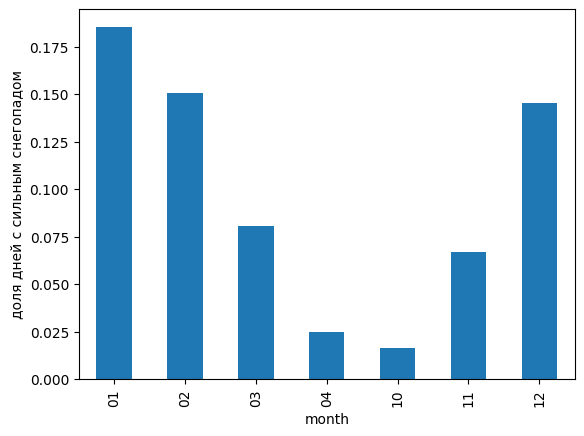

In [38]:
# в какие месяцы сильные снегопады бывают чаще
train.groupby("month")["heavy"].mean().plot.bar()
plt.ylabel("доля дней с сильным снегопадом")
plt.show()

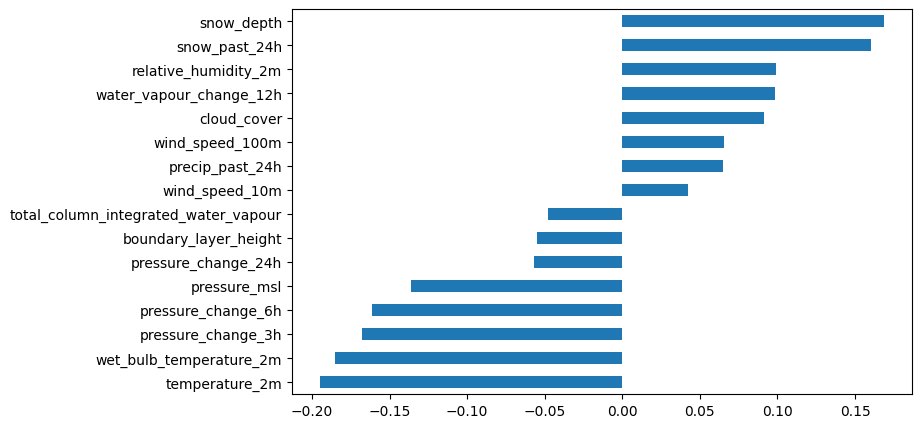

In [39]:
# какие признаки больше связаны с сильным снегопадом
train[cols + ["heavy"]].corr()["heavy"].drop("heavy").sort_values().plot.barh(figsize=(8, 5))
plt.show()

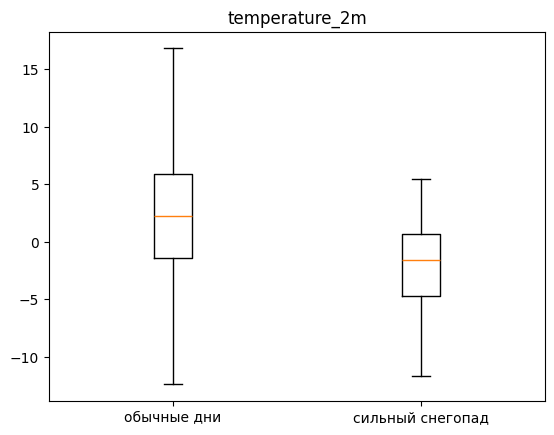

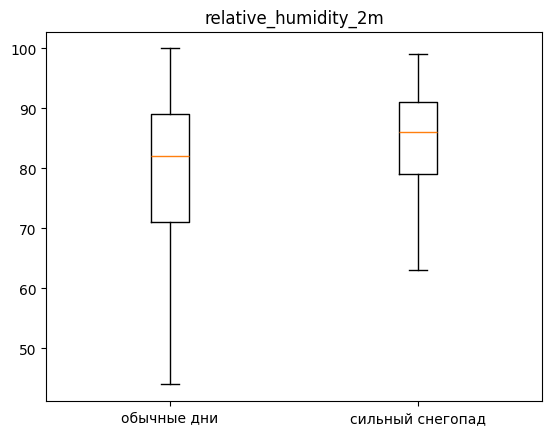

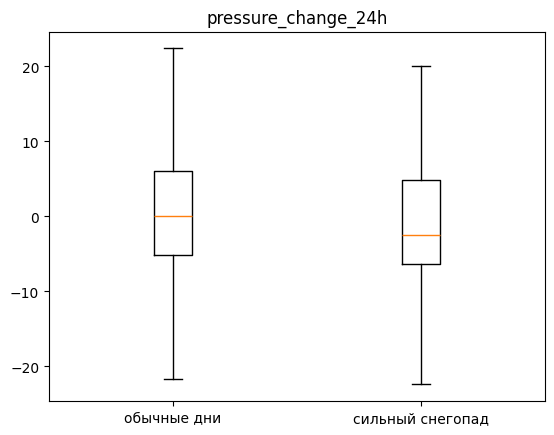

In [40]:
# как отличаются признаки в обычные дни и в дни с сильным снегопадом
for col in ["temperature_2m", "relative_humidity_2m", "pressure_change_24h"]:
    plt.boxplot([train[train["heavy"] == 0][col], train[train["heavy"] == 1][col]],
                tick_labels=["обычные дни", "сильный снегопад"], showfliers=False)
    plt.title(col)
    plt.show()

**Что видно** - сильные снегопады редкие, чаще бывают зимой, а перед ними отличаются температура, влажность и изменение давления.

**Пропуски и выбросы.** Экстремальные значения (например, сильный ветер) - это настоящая погода, а не ошибки, поэтому мы их не удаляем.

## Пятый этап - подготовка признаков

kNN сравнивает дни по "расстоянию". Но давление измеряется числами около 1000, а изменение давления - единицами. Из-за этого давление сильно влияло бы на остальные признаки. Поэтому делаем **стандартизацию**: из каждого числа вычитаем среднее и делим на разброс. После этого все признаки примерно от -2 до 2 и вносят сопоставимый вклад.

Среднее и разброс считаем **только по train**, а потом применяем к val и test (иначе в подготовку попадёт информация из "будущего").

In [41]:
def make_X(num_cols):
    # собираем таблицу признаков - числовые + колонки с метками
    cols = num_cols + dummy_cols
    X_train = train[cols].copy()
    X_val = val[cols].copy()
    X_test = test[cols].copy()

    # среднее и разброс - только по train
    mean = X_train[num_cols].mean()
    std = X_train[num_cols].std()

    for X in (X_train, X_val, X_test):
        X[num_cols] = (X[num_cols] - mean) / std

    return X_train.to_numpy(), X_val.to_numpy(), X_test.to_numpy()

In [42]:
 # берём все признаки из списка cols

X_train, X_val, X_test = make_X(cols)
print("Размер таблицы признаков (train):", X_train.shape)

Размер таблицы признаков (train): (849, 36)


## Шестой этап - простые модели для сравнения (baseline)

**Baseline** - очень простое решение. Если наша модель не лучше него, то она бесполезна. Возьмём три:
1. "Никогда не будет снегопада" - всегда отвечает "нет".
2. "По месяцу" - вероятность снегопада равна доле сильных снегопадов в этом месяце в train.
3. "Как вчера" - если за последние сутки выпало 2 см и больше, то скажем, что и дальше будет сильный снегопад.

### Как измеряем качество
Сильные снегопады редкие (меньше 10% дней), поэтому **accuracy** (доля верных ответов) здесь не годится: ответ "никогда не будет" верен в 90%+ случаев, но бесполезен. Используем:

* **recall** - какую часть настоящих снегопадов мы нашли. Было 10 снегопадов, нашли 4 - recall 0.4.
* **precision** - какая часть наших тревог оказалась верной. Подали 20 тревог, верных 6 - precision 0.3.
* **F1** - гармоническое среднее между точностью и полнотой.
* **PR_AUC** (average precision) - оценка того, насколько хорошо модель вообще сортирует дни от "вряд ли" до "очень вероятно". У случайного угадывания она равна доле снегопадов (около 0.06-0.10). Всё, что выше - это польза от модели.

**Порог** - число от 0 до 1. Если вероятность снегопада от модели выше порога, считаем это тревогой. Порог мы подбираем на val так, чтобы F1 было как можно больше.

In [43]:
def find_best_threshold(y, proba):
    # перебираем все пороги и берём тот, где F1 лучше всего
    best_threshold = 0.5
    best_f1 = -1
    for t in np.unique(proba):
        f1 = f1_score(y, proba >= t, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
    return best_threshold

def get_metrics(y, proba, threshold):
    alarm = (proba >= threshold).astype(int)     # 1 - тревога, 0 - нет
    return {"PR_AUC": average_precision_score(y, proba),
            "precision": precision_score(y, alarm, zero_division=0),
            "recall": recall_score(y, alarm, zero_division=0),
            "F1": f1_score(y, alarm, zero_division=0),
            "тревог": int(alarm.sum()),
            "поймали": int(((alarm == 1) & (y == 1)).sum()),
            "всего снегопадов": int(y.sum())}

results = []   # сюда будем складывать результаты всех моделей

def add_result(model_name, split_name, y, proba, threshold):
    row = {"модель": model_name, "выборка": split_name}
    row.update(get_metrics(y, proba, threshold))
    results.append(row)

splits = {"train": (train, y_train), "val": (val, y_val), "test": (test, y_test)}

In [44]:
# baseline 1: никогда не тревога
for split_name, (d, y) in splits.items():
    add_result("baseline: никогда не тревога", split_name, y, np.zeros(len(y)), 1.0)

# baseline 2: вероятность по месяцу (доля сильных снегопадов в этом месяце в train)
month_share = train.groupby("month")["heavy"].mean()
threshold_month = find_best_threshold(y_val, val["month"].map(month_share).to_numpy())
for split_name, (d, y) in splits.items():
    add_result("baseline: по месяцу", split_name, y, d["month"].map(month_share).to_numpy(), threshold_month)

# baseline 3: как вчера если за прошлые сутки выпало 2 см и больше - тревога
for split_name, (d, y) in splits.items():
    add_result("baseline: как вчера", split_name, y, d["snow_past_24h"].to_numpy(), 2.0)

pd.DataFrame(results).round(3)

,модель,выборка,PR_AUC,precision,recall,F1,тревог,поймали,всего снегопадов
0,baseline: никогда не тревога,train,0.095,0.000,0.000,0.000,0,0,81
1,baseline: никогда не тревога,val,0.118,0.000,0.000,0.000,0,0,50
2,baseline: никогда не тревога,test,0.052,0.000,0.000,0.000,0,0,11
3,baseline: по месяцу,train,0.160,0.140,0.840,0.240,485,68,81
4,baseline: по месяцу,val,0.174,0.178,0.860,0.295,242,43,50
5,baseline: по месяцу,test,0.095,0.066,0.727,0.121,121,8,11
6,baseline: как вчера,train,0.184,0.160,0.160,0.160,81,13,81
7,baseline: как вчера,val,0.199,0.240,0.240,0.240,50,12,50
8,baseline: как вчера,test,0.179,0.182,0.182,0.182,11,2,11


## Седьмой этап - kNN из sklearn

Настройки модели (**гиперпараметры**), которые мы подбираем:
* `k` - сколько соседей учитывать. Мало (3) - модель «нервная», зависит от случайных соседей. Много (100) - всё усредняется, и редкие снегопады пропадают;
* `weights` - `uniform`: все соседи равноценны; `distance`: ближние соседи важнее;
* `p` - как считать расстояние: `p=2` обычное (по прямой), `p=1` по осям, как по кварталам города.

Перебираем все сочетания и для каждого смотрим качество (PR_AUC) на train и на val. Лучшим считаем сочетание с лучшим качеством на **val**.

In [45]:
def sk_knn_proba(X_train, y_train, X_new, k, weights, p):
    # kNN из библиотеки: возвращает вероятность сильного снегопада для каждого дня из X_new
    model = KNeighborsClassifier(n_neighbors=k, weights=weights, p=p)
    model.fit(X_train, y_train)
    return model.predict_proba(X_new)[:, 1]

def run_grid(knn_function):
    # перебираем все сочетания настроек
    rows = []
    for k in [3, 5, 7, 10, 15, 20, 30, 50, 75, 100]:
        for weights in ["uniform", "distance"]:
            for p in [1, 2]:
                proba_train = knn_function(X_train, y_train, X_train, k, weights, p)
                proba_val = knn_function(X_train, y_train, X_val, k, weights, p)
                rows.append([k, weights, p,
                             average_precision_score(y_train, proba_train),
                             average_precision_score(y_val, proba_val)])
    table = pd.DataFrame(rows, columns=["k", "weights", "p", "train_AP", "val_AP"])
    return table.sort_values("val_AP", ascending=False).reset_index(drop=True)

table_sk = run_grid(sk_knn_proba)
table_sk.head(10).round(3)

,k,weights,p,train_AP,val_AP
0,75,distance,2,1.000,0.326
1,30,distance,1,1.000,0.324
2,100,distance,2,1.000,0.324
3,75,uniform,2,0.335,0.318
4,100,uniform,2,0.316,0.315
5,20,distance,1,1.000,0.305
6,50,distance,2,1.000,0.302
7,100,distance,1,1.000,0.300
8,50,distance,1,1.000,0.295
9,30,uniform,1,0.370,0.292


In [56]:
best = table_sk.iloc[0]
best_k = int(best["k"])
best_weights = best["weights"]
best_p = int(best["p"])
print("лучшие настройки - k =", best_k, "| weights =", best_weights, "| p =", best_p)

лучшие настройки - k = 75 | weights = distance | p = 2


### График: качество при разных k

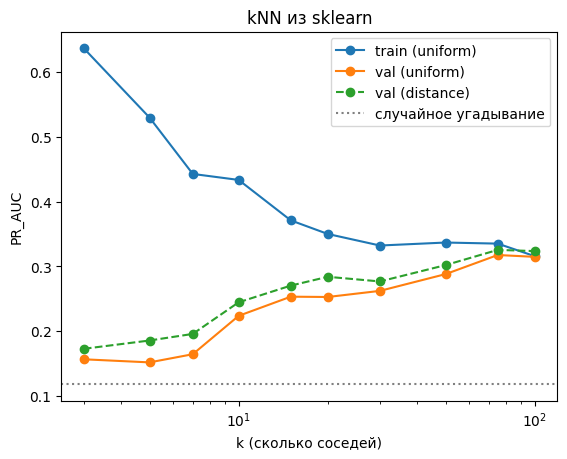

In [47]:
def plot_curve(table, title):
    best = table.iloc[0]
    for weights, style in [("uniform", "-"), ("distance", "--")]:
        part = table[(table["weights"] == weights) & (table["p"] == best["p"])].sort_values("k")
        if weights == "uniform":
            plt.plot(part["k"], part["train_AP"], style, marker="o", label="train (uniform)")
        plt.plot(part["k"], part["val_AP"], style, marker="o", label="val (" + weights + ")")
    plt.axhline(y_val.mean(), color="gray", linestyle=":", label="случайное угадывание")
    plt.xscale("log")
    plt.xlabel("k (сколько соседей)")
    plt.ylabel("PR_AUC")
    plt.title(title)
    plt.legend()
    plt.show()

plot_curve(table_sk, "kNN из sklearn")

Порог вероятности: 0.166


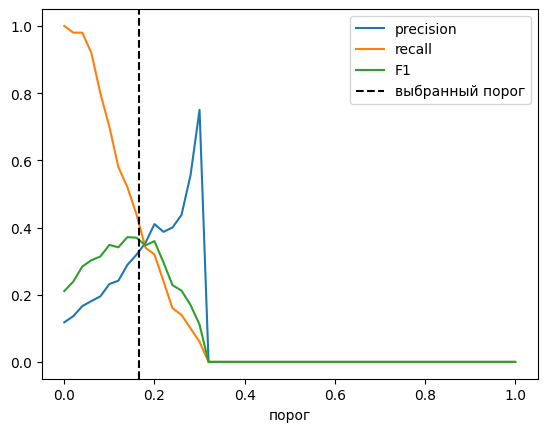

In [48]:
# вероятности для лучшей модели
proba_sk = {
    "train": sk_knn_proba(X_train, y_train, X_train, best_k, best_weights, best_p),
    "val": sk_knn_proba(X_train, y_train, X_val, best_k, best_weights, best_p),
    "test": sk_knn_proba(X_train, y_train, X_test, best_k, best_weights, best_p),
}

# порог выбираем на val (по лучшему F1)
threshold_sk = find_best_threshold(y_val, proba_sk["val"])
print("Порог вероятности:", round(threshold_sk, 3))

# Как меняются precision, recall и F1 при разном пороге (на val)
thresholds = np.arange(0, 1.01, 0.02)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    alarm = (proba_sk["val"] >= t).astype(int)
    precisions.append(precision_score(y_val, alarm, zero_division=0))
    recalls.append(recall_score(y_val, alarm, zero_division=0))
    f1s.append(f1_score(y_val, alarm, zero_division=0))
plt.plot(thresholds, precisions, label="precision")
plt.plot(thresholds, recalls, label="recall")
plt.plot(thresholds, f1s, label="F1")
plt.axvline(threshold_sk, color="black", linestyle="--", label="выбранный порог")
plt.xlabel("порог")
plt.legend()
plt.show()

for split_name, (d, y) in splits.items():
    add_result("kNN sklearn", split_name, y, proba_sk[split_name], threshold_sk)

                         прогноз: нет  прогноз: тревога
на самом деле: нет                182                19
на самом деле: снегопад             6                 5


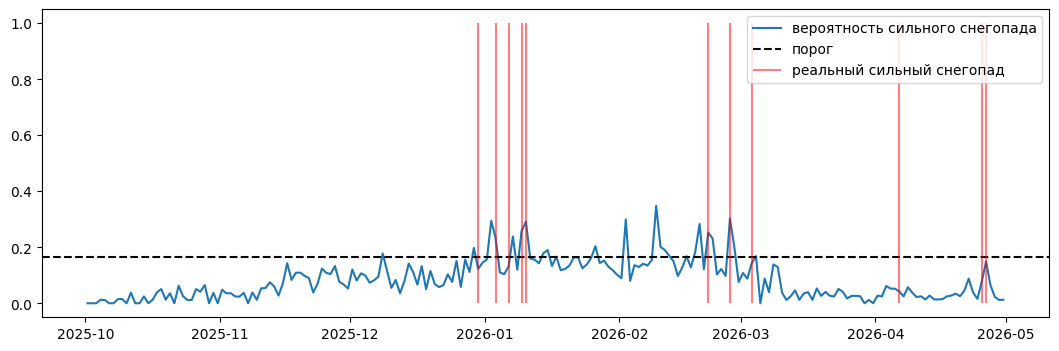

,snow_next_24h,вероятность,результат
time,,,
2025-12-30 12:00:00,3.50,0.12,пропустили
2026-01-03 12:00:00,2.66,0.23,поймали
2026-01-06 12:00:00,2.52,0.13,пропустили
2026-01-09 12:00:00,3.08,0.26,поймали
2026-01-10 12:00:00,2.10,0.29,поймали
2026-02-21 12:00:00,3.92,0.25,поймали
2026-02-26 12:00:00,10.15,0.30,поймали
2026-03-03 12:00:00,2.17,0.14,пропустили
2026-04-06 12:00:00,2.52,0.04,пропустили


In [49]:
# Матрица ошибок на test: сколько дней мы угадали и ошиблись
alarm_test = (proba_sk["test"] >= threshold_sk).astype(int)
print(pd.DataFrame(confusion_matrix(y_test, alarm_test),
                   index=["на самом деле: нет", "на самом деле: снегопад"],
                   columns=["прогноз: нет", "прогноз: тревога"]))

# Как выглядит прогноз на тестовом сезоне
plt.figure(figsize=(13, 4))
plt.plot(test.index, proba_sk["test"], label="вероятность сильного снегопада")
plt.axhline(threshold_sk, color="black", linestyle="--", label="порог")
plt.vlines(test.index[y_test == 1], 0, 1, color="red", alpha=0.5, label="реальный сильный снегопад")
plt.legend()
plt.show()

# Все реальные сильные снегопады на test: поймали или пропустили
missed = test[y_test == 1][["snow_next_24h"]].copy()
missed["вероятность"] = proba_sk["test"][y_test == 1]
missed["результат"] = np.where(missed["вероятность"] >= threshold_sk, "поймали", "пропустили")
missed.round(2)

## Восьмой этап - своя kNN

Пишем kNN сами. Для каждого нового дня:
1. считаем расстояние до **каждого** дня из train (чем меньше, тем более похожа погода);
2. берём `k` самых близких;
3. смотрим, в какой доле из них был сильный снегопад - это вероятность (при `weights="distance"` ближние дни считаются важнее).

В нашей версии те же настройки: `k`, `weights`, `p`, плюс порог.

In [50]:
def my_knn_proba(X_train, y_train, X_new, k, weights, p):
    result = []
    for day in X_new: # берём по одному дню
        # расстояние от этого дня до всех дней из train
        diff = np.abs(X_train - day)
        distance = (diff ** p).sum(axis=1) ** (1 / p)

        # номера k самых близких дней
        nearest = np.argsort(distance)[:k]

        # вес каждого соседа
        if weights == "distance":
            w = 1 / (distance[nearest] + 1e-9) # +1e-9 чтобы не делить на ноль
        else:
            w = np.ones(k)

        # вероятность = (взвешенная) доля сильных снегопадов среди соседей
        result.append((w * y_train[nearest]).sum() / w.sum())
    return np.array(result)

# Проверка на маленьком примере: дни 0, 1, 2, 10 с ответами 0, 0, 1, 1
toy_X = np.array([[0.0], [1.0], [2.0], [10.0]])
toy_y = np.array([0, 0, 1, 1])
print(my_knn_proba(toy_X, toy_y, np.array([[0.4], [9.0]]), 3, "uniform", 2))   # ожидаем [0.333 0.667]

[0.33333333 0.66666667]


In [51]:
# Перебор настроек для своей kNN (так же, как для sklearn)
table_my = run_grid(my_knn_proba)
table_my.head(10).round(3)

,k,weights,p,train_AP,val_AP
0,75,distance,2,1.000,0.326
1,30,distance,1,1.000,0.324
2,100,distance,2,1.000,0.324
3,75,uniform,2,0.335,0.318
4,100,uniform,2,0.316,0.315
5,20,distance,1,1.000,0.305
6,50,distance,2,1.000,0.302
7,100,distance,1,1.000,0.300
8,50,distance,1,1.000,0.295
9,30,uniform,1,0.370,0.292


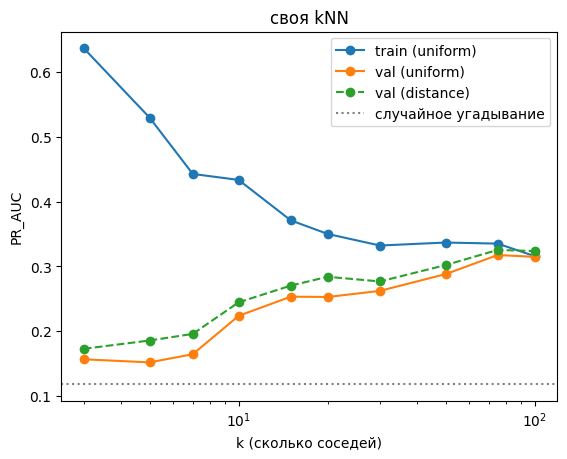

In [52]:
plot_curve(table_my, "своя kNN")

In [53]:
proba_my = {
    "train": my_knn_proba(X_train, y_train, X_train, best_k, best_weights, best_p),
    "val": my_knn_proba(X_train, y_train, X_val, best_k, best_weights, best_p),
    "test": my_knn_proba(X_train, y_train, X_test, best_k, best_weights, best_p),
}
threshold_my = find_best_threshold(y_val, proba_my["val"])
print("Порог моей модели:", round(threshold_my, 3), "| порог sklearn:", round(threshold_sk, 3))

for split_name, (d, y) in splits.items():
    add_result("kNN своя", split_name, y, proba_my[split_name], threshold_my)

# Насколько вероятности отличаются от sklearn (должно быть почти 0)
for split_name in ["train", "val", "test"]:
    print(split_name, "максимальная разница:", np.abs(proba_sk[split_name] - proba_my[split_name]).max())

Порог моей модели: 0.166 | порог sklearn: 0.166
train максимальная разница: 1.854877771823027e-06
val максимальная разница: 8.438666432297737e-12
test максимальная разница: 1.7051832168490932e-11


## Девятый этап - сравнение

In [54]:
final_table = pd.DataFrame(results).set_index(["модель", "выборка"])
final_table.round(3)

PR_AUC  precision  recall     F1  \
модель                       выборка                                     
baseline: никогда не тревога train     0.095      0.000   0.000  0.000   
                             val       0.118      0.000   0.000  0.000   
                             test      0.052      0.000   0.000  0.000   
baseline: по месяцу          train     0.160      0.140   0.840  0.240   
                             val       0.174      0.178   0.860  0.295   
                             test      0.095      0.066   0.727  0.121   
baseline: как вчера          train     0.184      0.160   0.160  0.160   
                             val       0.199      0.240   0.240  0.240   
                             test      0.179      0.182   0.182  0.182   
kNN sklearn                  train     1.000      1.000   1.000  1.000   
                             val       0.326      0.344   0.440  0.386   
                             test      0.287      0.208   0.455  0.286   
kNN своя                     train     1.000      1.000   1.000  1.000   
                             val       0.326      0.344   0.440  0.386   
                             test      0.287      0.208   0.455  0.286   

                                      тревог  поймали  всего снегопадов  
модель                       выборка                                     
baseline: никогда не тревога train         0        0                81  
                             val           0        0                50  
                             test          0        0                11  
baseline: по месяцу          train       485       68                81  
                             val         242       43                50  
                             test        121        8                11  
baseline: как вчера          train        81       13                81  
                             val          50       12                50  
                             test         11        2                11  
kNN sklearn                  train        81       81                81  
                             val          64       22                50  
                             test         24        5                11  
kNN своя                     train        81       81                81  
                             val          64       22                50  
                             test         24        5                11

In [55]:
print("случайное угадывание даёт PR_AUC =", round(y_test.mean(), 3), "(доля снегопадов на test)")

случайное угадывание даёт PR_AUC = 0.052 (доля снегопадов на test)


 ### Данные.
  1485 дней (по одному в сутки в октябре-апреле), полных сезонов - 7.
  Сильных снегопадов (2 см и больше за 24 часа) - 9.6% дней - классы несбалансированы. Поэтому качество считали через precision, recall, F1 и PR_AUC, а не через accuracy. Разбиение по сезонам: train [2018, 2019, 2020, 2021], val [2022, 2024], test [2025].

### Признаки.
  Использовано числовых признаков: 16 (плюс метки месяца, типа погоды и стороны ветра).

### Baseline.
Лучший простой вариант - "baseline: как вчера": PR_AUC на test 0.18, F1 0.18.

### Лучшая kNN.
Настройки подобраны по val: k = 75, weights = distance, p = 2, порог вероятности = 0.17.

### Качество на test.
PR_AUC = 0.29 (на val 0.33), случайное угадывание дало бы 0.05. Модель в 5.5 раза выше случайного - это заметно лучше случайного угадывания. По PR_AUC модель лучше лучшего baseline (0.29 против 0.18), по F1 0.29 против 0.18. Из 11 сильных снегопадов поймали 5 (recall = 0.45), всего было 24 тревог, из них верных 5 (precision = 0.21).

### Переобучение.
При k = 3 (weights = uniform) PR_AUC на train 0.64, на val 0.16 (разрыв 0.48) - сильное переобучение. При выбранном k = 75 разрыв 0.02.

### Что пропустили.
На test не поймали 6 из 11 снегопадов. Самый сильный снегопад на test - 10.2 см, его поймали.

### Своя kNN и sklearn.
Максимальная разница вероятностей на test = 1.7e-11, результаты совпадают.

### Ограничения.
Данные одной точки (без карт давления и прогнозов) дают лишь часть информации о циклоне, а событий в выборке мало (на test их 11), поэтому оценка на одном сезоне неточная.